## Load Shelter Data

In [56]:
# Import Pandas and Load Shelter Data From 2021 to 2022
import pandas as pd

s2021 = pd.read_csv("daily-shelter-overnight-service-occupancy-capacity-2021.csv")
s2022 = pd.read_csv("daily-shelter-overnight-service-occupancy-capacity-2022.csv")

print("2021 Shelter Shape:", s2021.shape)
print("2022 Shelter Shape:", s2022.shape)

2021 Shelter Shape: (50944, 32)
2022 Shelter Shape: (49478, 32)


In [57]:
# Combine 2021 and 2022 into a single dataframe
shelter = pd.concat([s2021, s2022])

shelter.head()

,_id,OCCUPANCY_DATE,ORGANIZATION_ID,ORGANIZATION_NAME,SHELTER_ID,SHELTER_GROUP,LOCATION_ID,LOCATION_NAME,LOCATION_ADDRESS,LOCATION_POSTAL_CODE,...,OCCUPIED_BEDS,UNOCCUPIED_BEDS,UNAVAILABLE_BEDS,CAPACITY_ACTUAL_ROOM,CAPACITY_FUNDING_ROOM,OCCUPIED_ROOMS,UNOCCUPIED_ROOMS,UNAVAILABLE_ROOMS,OCCUPANCY_RATE_BEDS,OCCUPANCY_RATE_ROOMS
0,1,21-01-01,24,COSTI Immigrant Services,40,COSTI Reception Centre,1103.0,COSTI/City North York West Hotel Program,1677 Wilson Ave,M3L 1A5,...,NaN,NaN,NaN,29.0,58.0,26.0,3.0,29.0,NaN,89.66
1,2,21-01-01,24,COSTI Immigrant Services,40,COSTI Reception Centre,1103.0,COSTI/City North York West Hotel Program,1677 Wilson Ave,M3L 1A5,...,NaN,NaN,NaN,3.0,0.0,3.0,0.0,0.0,NaN,100.00
2,3,21-01-01,24,COSTI Immigrant Services,40,COSTI Reception Centre,1103.0,COSTI/City North York West Hotel Program,1677 Wilson Ave,M3L 1A5,...,NaN,NaN,NaN,28.0,0.0,23.0,5.0,0.0,NaN,82.14
3,4,21-01-01,24,COSTI Immigrant Services,40,COSTI Reception Centre,1103.0,COSTI/City North York West Hotel Program,1677 Wilson Ave,M3L 1A5,...,NaN,NaN,NaN,17.0,0.0,17.0,0.0,0.0,NaN,100.00
4,5,21-01-01,24,COSTI Immigrant Services,40,COSTI Reception Centre,1103.0,COSTI/City North York West Hotel Program,1677 Wilson Ave,M3L 1A5,...,NaN,NaN,NaN,14.0,0.0,13.0,1.0,0.0,NaN,92.86


## Cleaning Shelter Data

In [58]:
# Clean and Filter Shelter Data for Downtown Toronto

# 1. Convert OCCUPANCY_DATE to datetime
shelter['OCCUPANCY_DATE'] = pd.to_datetime(shelter['OCCUPANCY_DATE'])

# 2. Make sure postal code is string (there can be NaNs)
shelter['LOCATION_POSTAL_CODE'] = shelter['LOCATION_POSTAL_CODE'].astype(str)

# 3. Define what we consider "downtown"
downtown_prefixes = ('M5', 'M4X', 'M4Y')

downtown_shelter = shelter[shelter['LOCATION_POSTAL_CODE'].str.startswith(downtown_prefixes)].copy()

C:\Users\wasay\AppData\Local\Temp\ipykernel_20452\1807534518.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shelter['OCCUPANCY_DATE'] = pd.to_datetime(shelter['OCCUPANCY_DATE'])


In [59]:
downtown_shelter[['OCCUPANCY_DATE', 'LOCATION_POSTAL_CODE', 'SERVICE_USER_COUNT']].head()

,OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SERVICE_USER_COUNT
5,2001-01-21,M5S 2P1,6
16,2001-01-21,M5A 3S7,5
17,2001-01-21,M5A 3G1,7
18,2001-01-21,M5A 2G6,26
19,2001-01-21,M5A 2G5,2


In [60]:
# Create daily and monthly homelessness metrics:

# Daily total number of service users in downtown shelters
daily_homeless = (
    downtown_shelter
    .groupby('OCCUPANCY_DATE', as_index = False)['SERVICE_USER_COUNT']
    .sum()
    .rename(columns = {
        'SERVICE_USER_COUNT': 'homeless_count'
    }))

daily_homeless.head()

,OCCUPANCY_DATE,homeless_count
0,2001-01-21,2503
1,2001-01-22,2868
2,2001-02-21,2445
3,2001-02-22,2899
4,2001-03-21,2381


In [61]:
# Convert to a Date index and resample monthly (mean per day in that month)
monthly_homeless = (
    daily_homeless
    .set_index('OCCUPANCY_DATE')
    .resample('MS')['homeless_count']   # 'MS' = month start
    .mean()
    .reset_index()
    .rename(columns = {
        'OCCUPANCY_DATE': 'month'
    }))

monthly_homeless.head()

,month,homeless_count
0,2001-01-01,2685.5
1,2001-02-01,2672.0
2,2001-03-01,2684.5
3,2001-04-01,2651.5
4,2001-05-01,2692.5


## Load Pedestrian Traffic Data

In [62]:
# Load traffic data and filter to downtown intersections

traffic = pd.read_csv("Traffic Volumes - Multimodal Intersection Turning Movement Counts.csv")

traffic.head()

,_id,latest_count_id,latest_count_date,location_name,longitude,latitude,centreline_type,centreline_id,px,count_duration,...,n_appr_heavy_pct,e_appr_vehicle,e_appr_bike,e_appr_heavy_pct,s_appr_vehicle,s_appr_bike,s_appr_heavy_pct,w_appr_vehicle,w_appr_bike,w_appr_heavy_pct
0,1,114830,2025-11-04,White Heather Blvd / Dragoon Cres,-79.266507,43.813129,2,13442259,NaN,14,...,0.022,0,0,0.000,1273,11,0.017,178,1,0.073
1,2,114831,2025-11-04,Briarscross Blvd / Chartland Blvd S,-79.269791,43.803227,2,13443082,5262.0,14,...,0.018,9,0,0.111,1285,28,0.033,414,6,0.024
2,3,114832,2025-11-04,Kenhatch Blvd / Sandhurst Crcl,-79.263787,43.805589,2,13442861,NaN,14,...,0.000,1124,2,0.007,764,7,0.014,1335,7,0.024
3,4,114278,2025-10-29,Danforth Ave / Royal Dr,-79.359421,43.676099,2,13462393,NaN,14,...,0.000,9590,1230,0.028,0,6,0.000,16007,1347,0.034
4,5,114809,2025-10-28,Morningside Ave / Passmore Ave,-79.241030,43.832681,2,30136531,NaN,14,...,0.087,258,6,0.702,0,2,0.000,1897,1,0.268


## Clean Pedestrian Traffic Data

In [63]:
# Clean traffic dates and filter by lat/long (downtown area)

# Convert date column to datetime
traffic['latest_count_date'] = pd.to_datetime(traffic['latest_count_date'])

# Here, I am defining a rough downtown bounding box/area
lat_min, lat_max = 43.640, 43.670
lon_min, lon_max = -79.410, -79.360

traffic_dt = traffic[
    (traffic['latitude'].between(lat_min, lat_max)) &
    (traffic['longitude'].between(lon_min, lon_max))
].copy()

traffic_dt[['latest_count_date', 'latitude', 'longitude', 'total_pedestrian']].head()

,latest_count_date,latitude,longitude,total_pedestrian
8,2025-10-22,43.659123,-79.367352,2768
29,2025-10-18,43.652295,-79.406013,14946
57,2025-10-15,43.653347,-79.386413,5946
58,2025-10-15,43.653835,-79.385414,5252
95,2025-10-07,43.644213,-79.366208,2107


In [64]:
# Build daily and monthly pedestrian counts for downtown

# Daily total pedestrians across all downtown intersections
daily_foot = (
    traffic_dt
    .groupby('latest_count_date', as_index = False)['total_pedestrian']
    .sum()
    .rename(columns = {
        'total_pedestrian': 'pedestrian_count'
    }))

daily_foot.head()

,latest_count_date,pedestrian_count
0,1984-01-18,2885
1,1984-09-17,1121
2,1989-05-03,10321
3,1989-11-09,3526
4,1990-07-23,3620


In [65]:
# Monthly average pedestrian count
monthly_foot = (
    daily_foot
    .set_index('latest_count_date')
    .resample('MS')['pedestrian_count']
    .mean()
    .reset_index()
    .rename(columns = {
        'latest_count_date': 'month'
    }))

monthly_foot.head()

,month,pedestrian_count
0,1984-01-01,2885.0
1,1984-02-01,NaN
2,1984-03-01,NaN
3,1984-04-01,NaN
4,1984-05-01,NaN


In [66]:
# Imputation for Missing Monthly Foot-Traffic Values

# Ensure monthly_foot has every month in 2021–2022
all_months = pd.date_range(start = start, end = end, freq = "MS")

monthly_foot = (
    monthly_foot
    .set_index("month")
    .reindex(all_months)              # insert missing months as NaN
    .rename_axis("month")
    .reset_index()
)

In [67]:
# Median imputation for pedestrian_count
median_ped = monthly_foot["pedestrian_count"].median(skipna = True)
monthly_foot["pedestrian_count"] = monthly_foot["pedestrian_count"].fillna(median_ped)

print("Monthly foot-traffic after imputation:")
monthly_foot

Monthly foot-traffic after imputation:
        month  pedestrian_count
0  2021-01-01            5740.5
1  2021-02-01            5740.5
2  2021-03-01            3663.0
3  2021-04-01            2230.0
4  2021-05-01            5740.5
5  2021-06-01            7641.0
6  2021-07-01            5740.5
7  2021-08-01            5608.5
8  2021-09-01            5740.5
9  2021-10-01            5740.5
10 2021-11-01            2821.5
11 2021-12-01            9960.0
12 2022-01-01            5740.5
13 2022-02-01           10608.0
14 2022-03-01           22447.5
15 2022-04-01            2418.0
16 2022-05-01            1612.0
17 2022-06-01           16101.0
18 2022-07-01            2630.0
19 2022-08-01            5740.5
20 2022-09-01            5740.5
21 2022-10-01            5740.5
22 2022-11-01            9944.0
23 2022-12-01            8783.0


## Load Retail Sales Data

In [99]:
# Clean Toronto Retail Sales Dataset

# Load Toronto retail dataset
toronto_retail = pd.read_csv("Retail_Sales_(in_$_Billions).csv")

# Convert date to datetime
toronto_retail['month'] = pd.to_datetime(toronto_retail['monthly'])

# Rename retail column
toronto_retail = toronto_retail.rename(columns = {'$': 'retail_billions'})

# Convert billions → actual dollars
toronto_retail['retail_dollars'] = toronto_retail['retail_billions'] * 1_000_000_000  

## Clean Retail Sales Data

In [98]:
# Filter to match your homelessness & foot traffic period
start = pd.to_datetime("2021-01-01")
end = pd.to_datetime("2022-12-31")

monthly_retail = (
    toronto_retail[
        (toronto_retail['month'] >= start) &
        (toronto_retail['month'] <= end)
    ][['month', 'retail_dollars']]
    .sort_values('month')
    .reset_index(drop=True)
)

monthly_retail.head()

,month,retail_dollars
0,2021-01-01,8.990000e+09
1,2021-02-01,9.030000e+09
2,2021-03-01,9.700000e+09
3,2021-04-01,8.670000e+09
4,2021-05-01,8.550000e+09


In [101]:
# Merge Monthly Datasets

# Ensure filtered monthly homelessness
mh = monthly_homeless[
    (monthly_homeless['month'] >= start) &
    (monthly_homeless['month'] <= end)
].copy()

# Ensure filtered monthly foot traffic
mf = monthly_foot[
    (monthly_foot['month'] >= start) &
    (monthly_foot['month'] <= end)
].copy()

# Toronto monthly retail already filtered as monthly_retail

print("Homeless rows:", len(mh))
print("Foot traffic rows:", len(mf))
print("Retail rows:", len(monthly_retail))

Homeless rows: 24
Foot traffic rows: 24
Retail rows: 24


In [100]:
# Merge on month (inner join)
merged = (
    mh.merge(mf, on = "month", how = "inner")
      .merge(monthly_retail, on = "month", how = "inner")
)

print("\nMerged dataset shape:", merged.shape)
merged.head()


Merged dataset shape: (24, 4)


,month,homeless_count,pedestrian_count,retail_dollars
0,2021-01-01,2617.0,5740.5,8.990000e+09
1,2021-02-01,2658.0,5740.5,9.030000e+09
2,2021-03-01,2654.5,3663.0,9.700000e+09
3,2021-04-01,2674.5,2230.0,8.670000e+09
4,2021-05-01,2786.0,5740.5,8.550000e+09


## Summary Statistics

In [88]:
# Basic summary stats for the three main variables

summary_stats = merged[["retail_dollars", "homeless_count", "pedestrian_count"]].describe()
print("Summary statistics:\n")
summary_stats

Summary statistics:



,retail_dollars,homeless_count,pedestrian_count
count,2.400000e+01,24.000000,24.000000
mean,1.044875e+10,2775.958333,6828.020833
std,9.372407e+08,99.828648,4630.006842
min,8.550000e+09,2617.000000,1612.000000
25%,9.947500e+09,2670.375000,5122.125000
50%,1.066500e+10,2806.750000,5740.500000
75%,1.121500e+10,2829.750000,7926.500000
max,1.191000e+10,2958.000000,22447.500000


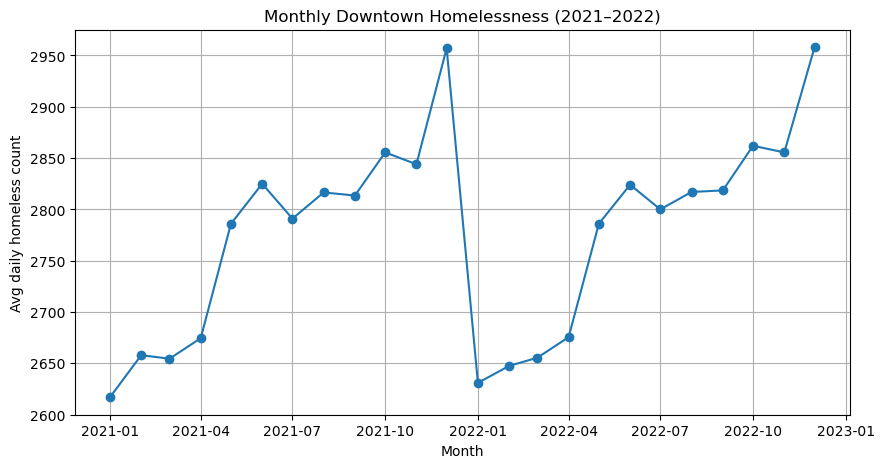

In [71]:
# Plot Monthly Trends

import matplotlib.pyplot as plt

# 1) Monthly downtown homelessness
plt.figure(figsize = (10, 5))
plt.plot(mh['month'], mh['homeless_count'], marker = "o")
plt.xlabel("Month")
plt.ylabel("Avg daily homeless count")
plt.title("Monthly Downtown Homelessness (2021–2022)")
plt.grid(True)
plt.show()

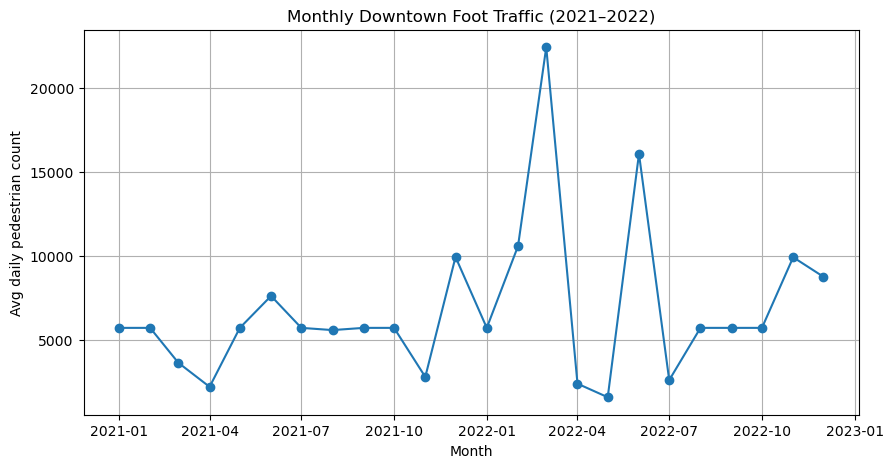

In [72]:
# 2) Monthly downtown foot traffic
plt.figure(figsize = (10, 5))
plt.plot(mf['month'], mf['pedestrian_count'], marker = "o")
plt.xlabel("Month")
plt.ylabel("Avg daily pedestrian count")
plt.title("Monthly Downtown Foot Traffic (2021–2022)")
plt.grid(True)
plt.show()

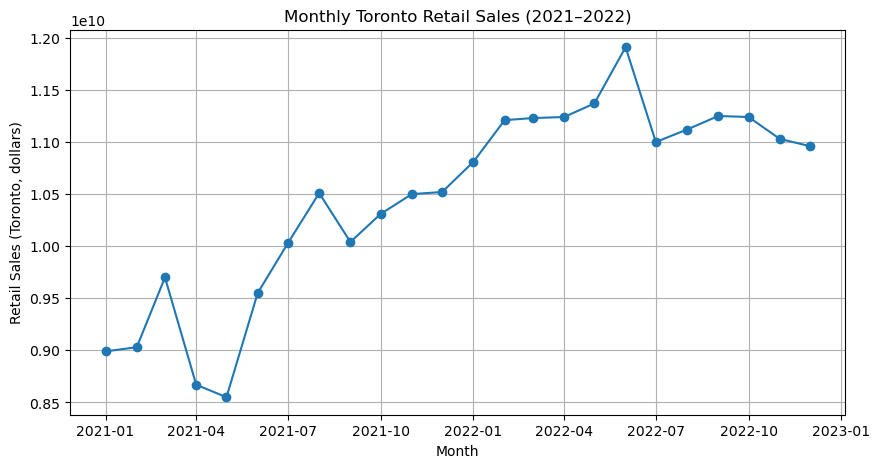

In [73]:
# 3) Monthly Toronto retail sales
plt.figure(figsize = (10, 5))
plt.plot(monthly_retail['month'], monthly_retail['retail_dollars'], marker = "o")
plt.xlabel("Month")
plt.ylabel("Retail Sales (Toronto, dollars)")
plt.title("Monthly Toronto Retail Sales (2021–2022)")
plt.grid(True)
plt.show()

## Multiple Linear Regression

In [97]:
# Multiple Linear Regression

import statsmodels.formula.api as smf

# Clean regression data
reg_data = merged.dropna().copy()

print("Rows used for regression:", len(reg_data))
reg_data.head()

Rows used for regression: 24


,month,homeless_count,pedestrian_count,retail_dollars
0,2021-01-01,2617.0,5740.5,8.990000e+09
1,2021-02-01,2658.0,5740.5,9.030000e+09
2,2021-03-01,2654.5,3663.0,9.700000e+09
3,2021-04-01,2674.5,2230.0,8.670000e+09
4,2021-05-01,2786.0,5740.5,8.550000e+09


In [96]:
# Regression model:
Model = smf.ols(
    formula = "retail_dollars ~ homeless_count + pedestrian_count",
    data = reg_data
).fit()

Model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         retail_dollars   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     2.591
Date:                Thu, 04 Dec 2025   Prob (F-statistic):             0.0987
Time:                        17:27:49   Log-Likelihood:                -526.70
No. Observations:                  24   AIC:                             1059.
Df Residuals:                      21   BIC:                             1063.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         2.523e+09    5.1e+09      0.495      0.626   -8.08e+09    1.31e+10
homeless_count    2.689e+06   1.84e+06      1.465      0.158   -1.13e+06    6.51e+06
pedestrian_count  6.769e+04   3.96e+04      1.711      0.102   -1.46e+04     1.5e+05
==============================================================================
Omnibus:                        0.867   Durbin-Watson:                   0.585
Prob(Omnibus):                  0.648   Jarque-Bera (JB):                0.876
Skew:                          -0.325   Prob(JB):                        0.645
Kurtosis:                       2.327   Cond. No.                     2.42e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.42e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Cross-Validation (Train on 2021, Validate on 2022)

In [90]:
# Cross Validation (Train 2021, Validate 2022)

import numpy as np

# Add year column
reg_data['year'] = reg_data['month'].dt.year

In [91]:
# Split datasets
TData = reg_data[reg_data['year'] == 2021]
VData = reg_data[reg_data['year'] == 2022]

print("Train rows (2021):", len(TData))
print("Validation rows (2022):", len(VData))

Train rows (2021): 12
Validation rows (2022): 12


In [95]:

# Fit model on training set
Model_CV = smf.ols(
    formula = "retail_dollars ~ homeless_count + pedestrian_count",
    data = TData
).fit()

print(Model_CV.summary())

                            OLS Regression Results                            
Dep. Variable:         retail_dollars   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     4.889
Date:                Thu, 04 Dec 2025   Prob (F-statistic):             0.0365
Time:                        17:27:27   Log-Likelihood:                -257.06
No. Observations:                  12   AIC:                             520.1
Df Residuals:                       9   BIC:                             521.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -6.049e+09   5.25e+09  

C:\Users\wasay\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [93]:
# Predictions
T_pred = Model_CV.predict(TData)
V_pred = Model_CV.predict(VData)

# RMSE Calculation
train_rmse = np.sqrt(np.mean((TData['retail_dollars'] - T_pred)**2))
valid_rmse = np.sqrt(np.mean((VData['retail_dollars'] - V_pred)**2))

print("\nModel Performance:")
print(f"Train RMSE (2021): {train_rmse:,.2f}")
print(f"Validation RMSE (2022): {valid_rmse:,.2f}")


Model Performance:
Train RMSE (2021): 486,416,922.43
Validation RMSE (2022): 1,830,438,439.84
